In [25]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from main import *
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

In [26]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([3 * np.ones(n_pos), np.ones(n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

In [27]:
#-----
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model

sigma_pos = 1.0
sigma_neg = 1.0

In [39]:
base_seed = 12345
loss_key = 'hinge' 
sigma_loss = 1.0 
c = 0.0001
d = 16# dimensions to run experiments on
T = 5 # 20  # number of trials
#-----

# choose parameters 
n_pos = 500 # number of data points in a sample with label 1
n_neg = 500 # number of data points in a sample with label -1
mu_scalar = 0.5
mu_pos = np.concatenate(([mu_scalar], np.zeros(d - 1)))
mu_neg = np.concatenate(([-mu_scalar], np.zeros(d - 1)))

In [ ]:
def compute_paymentss(t, N=100, oneshot_mus=[0.25, 0.4, 0.5, 0.6, 0.75]):
    """
    Compute payments for:
      - exact (deterministic)
      - random mechanism
      - oneshot with different mu values
    Each run is independent and reproducible.
    
    Parameters
    ----------
    t : int
        Trial index, used for seed
    N : int
        Number of random runs per mechanism
    oneshot_mus : list of floats
        mu values for oneshot mechanisms
    """
    dfs = []

    # ---- Base RNG for this trial
    ss = np.random.SeedSequence([base_seed, t, d, int(mu_scalar*1e6)])
    rng = np.random.default_rng(ss)

    # ---- Generate data once per trial
    x, y, v = generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d)

    svm_model = train_soft_svm(x, y, v, c, loss_key)

    train_acc = (svm_model.predict(x) == y).mean()

    print(f"SVM training accuracy: {train_acc:.4f}")

    train_welfare = np.sum((svm_model.predict(x) == y) * v) / np.sum(v)

    print(f"SVM training welfare: {train_welfare:.4f}")

    # ---- Exact run (deterministic)
    df, _ = run_simulation(x, y, v, c, loss_key, algorithm="exact", n_random=1, rng=None, k=None)
    df['t'] = t
    df['d'] = d
    df['label'] = y[df['agent'].astype(int)]
    df['calc'] = 'exact'
    dfs.append(df)

    #print(df['allocation'].mean(), df['welfare'].mean())

    # ---- Random runs and oneshot runs
    for n in range(1, N+1):
        for r in [1,3,6,9]:
            # Each run gets its own independent seed
            seed_random = int((t+1)*1e6 + n)
            rng_r = np.random.default_rng(seed_random)
            # Random mechanism using SVM
            df_random, _ = run_simulation(x, y, v, c, loss_key, algorithm="random", n_random=r, rng=rng_r)
            df_random['t'] = t
            df_random['d'] = d
            df_random['label'] = y[df_random['agent'].astype(int)]
            df_random['calc'] = f'random-{r}'
            df_random['n'] = n
            dfs.append(df_random)

        # Oneshoot runs with different mus
        for mu_val in oneshot_mus:
            df_oneshot, _ = run_simulation(x, y, v, c, loss_key, algorithm="one-shot", n_random=1, rng=rng_r)
            df_oneshot['t'] = t
            df_oneshot['d'] = d
            df_oneshot['label'] = y[df_oneshot['agent'].astype(int)]
            df_oneshot['calc'] = f'oneshot-{mu_val}'
            df_oneshot['n'] = n
            dfs.append(df_oneshot)

    
    return pd.concat(dfs, ignore_index=True)


In [ ]:
for i in range(T):
    df = compute_paymentss(i)

In [31]:
df = compute_paymentss(0)

SVM training accuracy: 0.6420
SVM training welfare: 0.7850


In [32]:
df.to_csv("data/payment_c=1_d=4.csv", index=False)

In [20]:
df = pd.read_csv("data/payment_c=1000_d=4.csv")

In [41]:
df[(df['calc'] == 'oneshot-0.75') & (df['agent'] == 0)]

,agent,allocation,true_v,is_throw,is_relevant,alloc 0 success,critical_v,welfare,utility,times_alloc_called,t,d,label,calc,n,pays
9000,0,1.0,3.0,NaN,NaN,NaN,-3.0,3.0,6.0,0.001,0,16,-1.0,oneshot-0.75,1.0,0
18000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,2.0,1
27000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,3.0,1
36000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,4.0,1
45000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,96.0,1
873000,0,1.0,3.0,NaN,NaN,NaN,-3.0,3.0,6.0,0.001,0,16,-1.0,oneshot-0.75,97.0,0
882000,0,1.0,3.0,NaN,NaN,NaN,-3.0,3.0,6.0,0.001,0,16,-1.0,oneshot-0.75,98.0,0
891000,0,1.0,3.0,NaN,NaN,NaN,3.0,3.0,0.0,0.001,0,16,-1.0,oneshot-0.75,99.0,1


In [34]:
df['pays'] = df['critical_v'] > 0

In [35]:
def create_df(df):
    df_summary_r = []
    
    for calc in df['calc'].unique():
        df_calc = df[df['calc'] == calc]

        if calc == 'exact':
            avg_welfare = (df_calc['welfare'].sum() / df_calc['true_v'].sum())
            avg_times_alloc_called = df_calc['times_alloc_called'].mean()
            #avg_utility = df_calc['utility'].mean()
            #accuracy = df_calc['allocation'].mean()
            avg_payment = df_calc['critical_v'].mean()
            #avg_relevant = df_calc['is_relevant'].sum()
            #number_payers = df_calc['pays'].sum()
            sum_payments = df_calc['critical_v'].sum()
            min_payment = df_calc[df_calc['critical_v'] > 0]['critical_v'].min()
            max_payment = df_calc['critical_v'].max()
            stdev_payment = df_calc['critical_v'].std()

            df_summary_r.append(pd.DataFrame({
                'calc': [calc],
                'avg_welfare': [avg_welfare],
                #'avg_utility': [avg_utility],
                # 'accuracy': [accuracy],
                'avg_payment': [avg_payment],
                'avg_times_alloc_called': [avg_times_alloc_called],
                #'sum_relevant': [avg_relevant],
                'sum_payments': [sum_payments],
                #'number_payers': [number_payers],
                'min_payment': [min_payment],
                'max_payment': [max_payment],
                'stdev_payment': [stdev_payment]
            }))

        else:
            df_summary = []

            for n in range(100):
                df_random = df_calc[df_calc['n'] == n]

                avg_welfare = df_random['welfare'].sum() / df_random['true_v'].sum()
                avg_times_alloc_called = df_random['times_alloc_called'].mean()
                # avg_utility = df_random['utility'].mean()
                # accuracy = df_random['allocation'].mean()
                avg_payment = df_random['critical_v'].mean()
                #avg_relevant = df_random['is_relevant'].sum()
                sum_payments = df_random['critical_v'].sum()
                # number_payers = df_random['pays'].sum()
                min_payment = df_random[df_random['critical_v'] > 0]['critical_v'].min()
                max_payment = df_random['critical_v'].max()
                stdev_payment = df_random['critical_v'].std()

                df_summary.append(pd.DataFrame({
                    'calc': [calc],
                    'n': [n],
                    'avg_welfare': [avg_welfare],
                    # 'avg_utility': [avg_utility],
                    # 'accuracy': [accuracy],
                    'avg_payment': [avg_payment],
                    'avg_times_alloc_called': [avg_times_alloc_called],
                    # 'sum_relevant': [avg_relevant],
                    'sum_payments': [sum_payments],
                    # 'number_payers': [number_payers],
                    'min_payment': [min_payment],
                    'max_payment': [max_payment],
                    'stdev_payment': [stdev_payment]
                }))

            df_summary = pd.concat(df_summary, ignore_index=True)
            print(f"Summary for {calc}:\n{df_summary}\n")

            # average over all rows in df_summary
            summary_line = pd.DataFrame({
                'calc': [calc],
                'avg_welfare': [df_summary['avg_welfare'].mean()],
                #'avg_utility': [df_summary['avg_utility'].mean()],
                #'accuracy': [df_summary['accuracy'].mean()],
                'avg_payment': [df_summary['avg_payment'].mean()],
                'avg_times_alloc_called': [df_summary['avg_times_alloc_called'].mean()],
                #'sum_relevant': [df_summary['sum_relevant'].mean()],
                'sum_payments': [df_summary['sum_payments'].mean()],
                #'number_payers': [df_summary['number_payers'].mean()],
                'min_payment': [df_summary['min_payment'].min()],
                'max_payment': [df_summary['max_payment'].max()],
                'stdev_payment': [df_summary['stdev_payment'].mean()]
            })

            # append averaged line to df_summary_r
            df_summary_r.append(summary_line)

    return pd.concat(df_summary_r, ignore_index=True)

In [36]:
df['pays'] = (df['critical_v'] > 0).astype(int)
df_summary_random_payments = create_df(df)

Summary for random-1:
        calc   n  avg_welfare  avg_payment  avg_times_alloc_called  \
0   random-1   0          NaN          NaN                     NaN   
1   random-1   1       0.7830        0.004                   0.125   
2   random-1   2       0.7830        0.004                   0.125   
3   random-1   3       0.7825        0.005                   0.125   
4   random-1   4       0.7825        0.005                   0.125   
..       ...  ..          ...          ...                     ...   
95  random-1  95       0.7840        0.002                   0.125   
96  random-1  96       0.7830        0.004                   0.125   
97  random-1  97       0.7825        0.005                   0.125   
98  random-1  98       0.7840        0.002                   0.125   
99  random-1  99       0.7840        0.002                   0.125   

    sum_payments  min_payment  max_payment  stdev_payment  
0            0.0          NaN          NaN            NaN  
1            4.0 

In [42]:
df_summary_random_payments

,calc,avg_welfare,avg_payment,avg_times_alloc_called,sum_payments,min_payment,max_payment,stdev_payment
0,exact,0.785000,0.003799,0.203,3.798600,0.137455,2.1471,0.076005
1,random-1,0.783051,0.003899,0.125,3.860000,1.000000,3.0000,0.085416
2,random-3,0.783084,0.003832,0.133,3.793333,0.333333,3.0000,0.080127
3,random-6,0.783093,0.003813,0.145,3.775000,0.166667,3.0000,0.077822
4,random-9,0.783090,0.003820,0.157,3.782222,0.111111,3.0000,0.076946
5,oneshot-0.25,0.781308,0.010273,0.001,10.170000,1.000000,3.0000,2.080917
6,oneshot-0.4,0.780222,-0.001515,0.001,-1.500000,1.000000,3.0000,2.079386
7,oneshot-0.5,0.781121,-0.002303,0.001,-2.280000,1.000000,3.0000,2.080956
8,oneshot-0.6,0.780172,-0.000384,0.001,-0.380000,1.000000,3.0000,2.079971
9,oneshot-0.75,0.780965,-0.003162,0.001,-3.130000,1.000000,3.0000,2.081170


In [162]:
df_summary_random_payments[['calc', 'avg_welfare', 'avg_times_alloc_called', 'avg_payment', 'min_payment', 'max_payment', 'stdev_payment']]

,calc,avg_welfare,avg_times_alloc_called,avg_payment,min_payment,max_payment,stdev_payment
0,exact,0.785000,0.203,0.003799,0.0,2.1471,0.076005
1,random-1,0.783051,0.125,0.003899,0.0,3.0000,0.085416
2,random-3,0.783084,0.133,0.003832,0.0,3.0000,0.080127
3,random-6,0.783093,0.145,0.003813,0.0,3.0000,0.077822
4,random-9,0.783090,0.157,0.003820,0.0,3.0000,0.076946
5,oneshot-0.25,0.781308,0.001,0.010273,-3.0,3.0000,2.080917
6,oneshot-0.4,0.780222,0.001,-0.001515,-3.0,3.0000,2.079386
7,oneshot-0.5,0.781121,0.001,-0.002303,-3.0,3.0000,2.080956
8,oneshot-0.6,0.780172,0.001,-0.000384,-3.0,3.0000,2.079971
9,oneshot-0.75,0.780965,0.001,-0.003162,-3.0,3.0000,2.081170


In [163]:
def create_df(df):
    df_summary_r = []
    
    for calc in df['calc'].unique():
        df_calc = df[df['calc'] == calc]

        if calc == 'exact':
            avg_welfare = (df_calc['welfare'].sum() / df_calc['true_v'].sum())
            avg_times_alloc_called = df_calc['times_alloc_called'].mean()
            avg_utility = df_calc['utility'].mean()
            accuracy = df_calc['allocation'].mean()
            avg_payment = df_calc['critical_v'].mean()
            avg_relevant = df_calc['is_relevant'].sum()
            number_payers = df_calc['pays'].sum()
            sum_payments = df_calc['critical_v'].sum()

            df_summary_r.append(pd.DataFrame({
                'calc': [calc],
                'avg_welfare': [avg_welfare],
                'avg_utility': [avg_utility],
                'accuracy': [accuracy],
                'avg_payment': [avg_payment],
                'avg_times_alloc_called': [avg_times_alloc_called],
                'sum_relevant': [avg_relevant],
                'sum_payments': [sum_payments] ,
                'number_payers': [number_payers]
            }))

        else:
            df_summary = []
            for n in range(100):
                df_random = df_calc[df_calc['n'] == n]
                avg_welfare = df_random['welfare'].sum() / df_random['true_v'].sum()
                avg_times_alloc_called = df_random['times_alloc_called'].mean()
                avg_utility = df_random['utility'].mean()
                accuracy = df_random['allocation'].mean()
                avg_payment = df_random['critical_v'].mean()
                avg_relevant = df_random['is_relevant'].sum()
                sum_payments = df_random['critical_v'].sum()
                number_payers = df_random['pays'].sum()

                df_summary.append(pd.DataFrame({
                    'calc': [calc],
                    'n': [n],
                    'avg_welfare': [avg_welfare],
                    'avg_utility': [avg_utility],
                    'accuracy': [accuracy],
                    'avg_payment': [avg_payment],
                    'avg_times_alloc_called': [avg_times_alloc_called],
                    'sum_relevant': [avg_relevant],
                    'sum_payments': [sum_payments],
                    'number_payers': [number_payers]
                }))
            
            df_summary = pd.concat(df_summary, ignore_index=True)

        


    df_summary = pd.concat(df_summary_r, ignore_index=True)

    # Drop n if  exists
    df_summary = df_summary.drop(columns=['n'], errors='ignore')

    # Extract parameter from calc
    df_summary['parameter'] = (
        df_summary['calc']
        .str.extract(r'-(\d+)')
        .astype(float)
    )

    return df_summary

In [164]:
#df = pd.read_csv("payment_c_parallel.csv")
df['pays'] = (df['critical_v'] > 0).astype(int)
df_summary_random_payments = create_df(df)
#df_summary_random_payments.to_csv("acc_auc/final_data/random_payments_summary.csv", index = False)

In [165]:
df_summary_random_payments

,calc,avg_welfare,avg_utility,accuracy,avg_payment,avg_times_alloc_called,sum_relevant,sum_payments,number_payers,parameter
0,exact,0.785,1.566201,0.642,0.003799,0.203,120.0,3.7986,4,NaN


In [5]:
def boxplot_payments_general(df):
    """
    Create boxplots of sum payments per mechanism with semi-transparent boxes.
    
    Parameters:
    - df: DataFrame with columns including 'calc', 't', 'n', 'critical_v'
    """
    data_for_plot = []
    labels = []

    for calc in df['calc'].unique():
        df_calc = df[df['calc'] == calc]

        if calc == 'exact':
            # Exact: just mean sum over t
            sum_val = df_calc.groupby('t')['critical_v'].sum().mean()
            data_for_plot.append([sum_val])
            labels.append(f'{calc} (mean)')
        else:
            df_random = df[df['calc'] == calc]
            random_sums = df_random.groupby(['t','n'])['critical_v'].sum().values
            data_for_plot.append(random_sums)

    # ---- Plot boxplots
    plt.figure(figsize=(8,6))
    box = plt.boxplot(data_for_plot, labels=df['calc'].unique(),
                      patch_artist=True, showfliers=False)  # hide default outliers

    # Make boxes semi-transparent
    for patch in box['boxes']:
        patch.set(facecolor='skyblue', alpha=0.3)  # alpha < 1 makes it see-through
    for median in box['medians']:
        median.set(color='blue', linewidth=2)

    # ---- Overlay all points
    for i, y in enumerate(data_for_plot, start=1):
        x = np.random.normal(i, 0.08, size=len(y))  # jitter x for visibility
        plt.scatter(x, y, alpha=0.6, color='black', s=20)

    plt.ylabel("Sum of payments (critical_v)")
    plt.title("Boxplots of payments per mechanism (all points)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# ---- Example usag



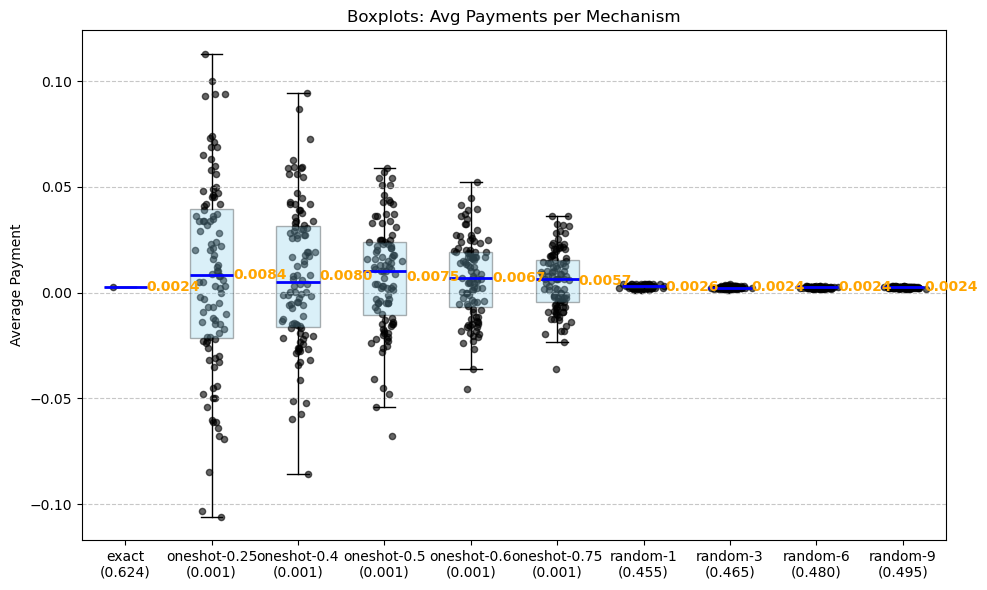

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def boxplot_payments_split(df):

    def plot_box(df_subset, title):
        data_for_plot = []
        labels = []

        for calc in sorted(df_subset['calc'].unique()):
            df_calc = df_subset[df_subset['calc'] == calc]

            # Take all avg_payment values as points
            y_vals = df_calc['avg_payment'].values
            data_for_plot.append(y_vals)

            # Compute mean(avg_payment / avg_times_alloc_called) for annotation
            mean_per_call = np.mean( df_calc['avg_times_alloc_called'])
            labels.append(f"{calc}\n({mean_per_call:.3f})")

        # ---- Plot boxplots
        plt.figure(figsize=(10,6))
        box = plt.boxplot(data_for_plot, labels=labels, patch_artist=True, showfliers=False)

        # Style boxes
        for patch in box['boxes']:
            patch.set(facecolor='skyblue', alpha=0.3)
        for median in box['medians']:
            median.set(color='blue', linewidth=2)

        # Overlay all points with jitter
        for i, y in enumerate(data_for_plot, start=1):
            x = np.random.normal(i, 0.08, size=len(y))  # jitter
            plt.scatter(x, y, alpha=0.6, color='black', s=20)
        
        # Overlay mean of avg_payment
        for i, y in enumerate(data_for_plot, start=1):
            mean_val = np.mean(y)
            plt.text(i + 0.25, mean_val, f"{mean_val:.4f}", 
                     ha='left', va='center', color='orange', fontweight='bold')

        plt.ylabel("Average Payment")
        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    # ---- Plot all calcs
    plot_box(df, "Boxplots: Avg Payments per Mechanism")


# ---- Usage
# boxplot_payments_split(df_summary_random_payments)

# ---- Usage
boxplot_payments_split(df_summary_random_payments)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os

def boxplot_payments_split(df, save_dir="plots"):
    """
    Create two boxplots:
    1) oneshot + exact
    2) random + exact
    Orange text shows mean(avg_payment) * 4
    Saves each plot in png, jpg, pdf, and eps formats.
    """

    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    def plot_box(df_subset, title, filename_prefix):
        data_for_plot = []
        labels = []

        for calc in sorted(df_subset['calc'].unique()):
            df_calc = df_subset[df_subset['calc'] == calc]

            # Points = avg_payment per row
            y_vals = df_calc['avg_payment'].values
            data_for_plot.append(y_vals)

            # Label = calc + mean(avg_times_alloc_called)
            mean_alloc = np.mean(df_calc['avg_times_alloc_called'])
            labels.append(f"{calc}\n({mean_alloc:.3f})")

        # ---- Plot boxplots
        plt.figure(figsize=(10,6))
        box = plt.boxplot(data_for_plot, labels=labels, patch_artist=True, showfliers=False)

        # Style boxes
        for patch in box['boxes']:
            patch.set(facecolor='skyblue', alpha=0.3)
        for median in box['medians']:
            median.set(color='blue', linewidth=2)

        # Overlay points with jitter
        for i, y in enumerate(data_for_plot, start=1):
            x = np.random.normal(i, 0.08, size=len(y))
            plt.scatter(x, y, alpha=0.6, color='black', s=20)

        # Overlay mean(avg_payment) * 4 in orange
        for i, y in enumerate(data_for_plot, start=1):
            mean_payment = np.mean(y) * 4
            plt.text(i + 0.25, np.mean(y), f"{mean_payment:.4f}",  # keep y-position at actual mean
                     ha='left', va='center', color='orange', fontweight='bold')

        plt.ylabel("Average Payment")
        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # ---- Save in multiple formats
        for ext in ["png", "jpg", "pdf", "eps"]:
            save_path = os.path.join(save_dir, f"{filename_prefix}.{ext}")
            plt.savefig(save_path, dpi=300)
            print(f"Saved: {save_path}")

        plt.show()

    # ---- Split the df
    oneshot_mask = df['calc'].str.startswith('oneshot') | (df['calc'] == 'exact')
    random_mask = df['calc'].str.startswith('random') | (df['calc'] == 'exact')

    # ---- Plot oneshot + exact
    if oneshot_mask.any():
        plot_box(df[oneshot_mask], "Boxplots: Oneshot + Exact Mechanisms", "oneshot_exact")

    # ---- Plot random + exact
    if random_mask.any():
        plot_box(df[random_mask], "Boxplots: Random + Exact Mechanisms", "random_exact")


Saved: plots/oneshot_exact.png
Saved: plots/oneshot_exact.jpg
Saved: plots/oneshot_exact.pdf


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/oneshot_exact.eps


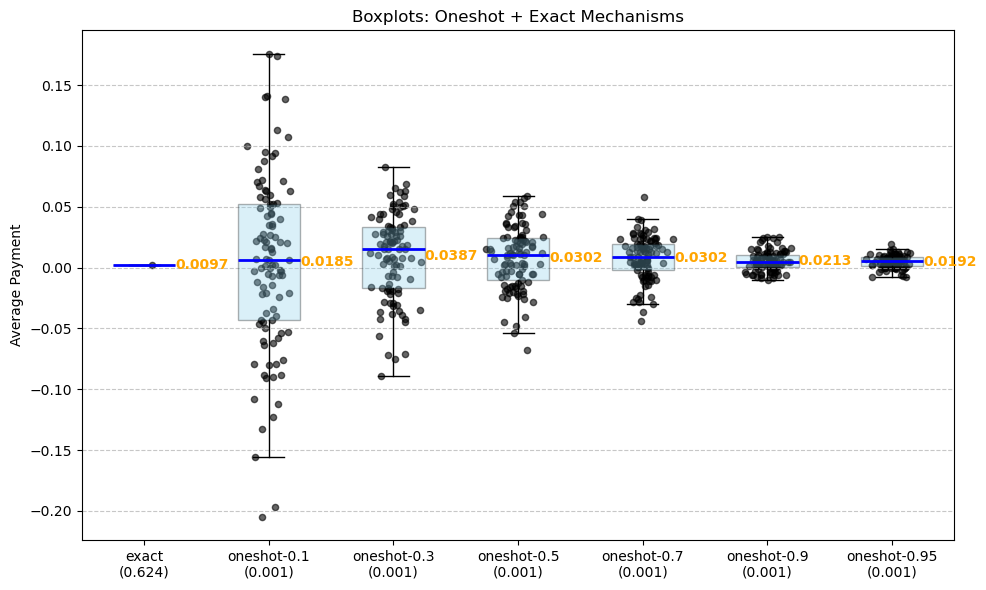

Saved: plots/random_exact.png


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/random_exact.jpg
Saved: plots/random_exact.pdf
Saved: plots/random_exact.eps


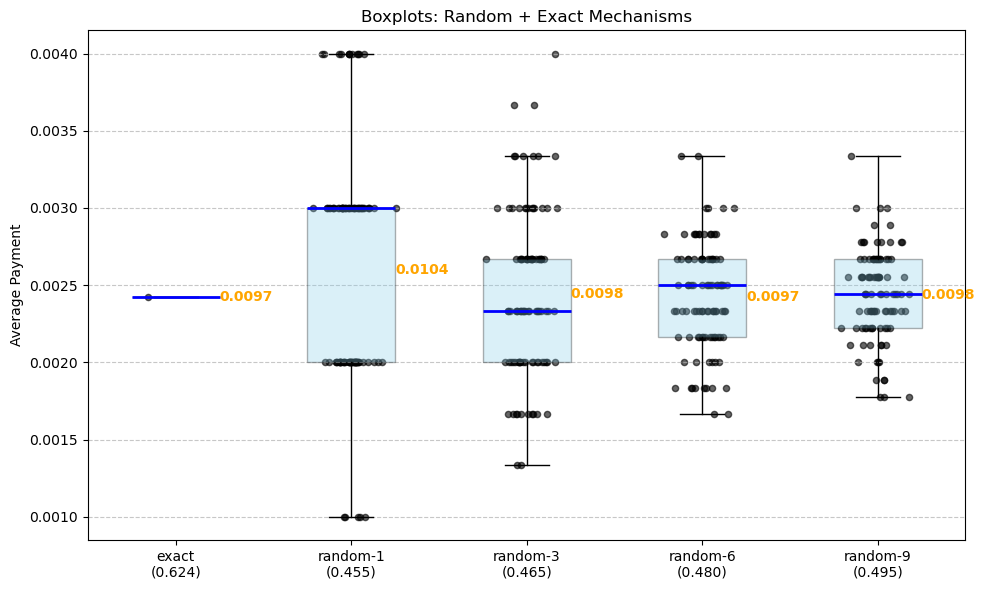

In [18]:
boxplot_payments_split(df_summary_random_payments)

In [ ]:
summary[summary['model'] != 'KNN-k=8']

,m,model,num_payers
0,25,KNN-k=2,26.0
1,25,KNN-k=4,17.0
2,25,KNN-k=6,12.0
3,25,KNN-k=8,11.0
4,25,SVM-exact,1.0
5,50,KNN-k=2,45.0
6,50,KNN-k=4,34.0
7,50,KNN-k=6,24.0
8,50,KNN-k=8,15.0
9,50,SVM-exact,3.0
